# **Regression Practice Notebook**

This notebook contains practice questions for three regression techniques:
1. Simple Linear Regression
2. Multiple Linear Regression
3. Gradient Boosting Regressor

Each section uses a different dataset. Write your code in the empty cells below each question.

## **Section 1: Simple Linear Regression**

**Dataset:** `study_hours_exam_score.csv`
**Shape:** (1000, 2)
**Columns:** `StudyHours` (input), `ExamScore` (output)

**Q1.** Import the required libraries (`pandas`, `matplotlib.pyplot`) and load `study_hours_exam_score.csv` into a DataFrame. Display the first 5 rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df1 = pd.read_csv('study_hours_exam_score.csv')
df1.head()

,StudyHours,ExamScore
0,5.59,56.64
1,8.92,74.03
2,1.00,25.87
3,4.33,48.35
4,2.61,25.43


**Q2.** Check the shape of the dataset and confirm there are no missing values.

In [2]:
print(df1.shape)
print(df1.isnull().sum())

(1000, 2)
StudyHours    0
ExamScore     0
dtype: int64


**Q3.** Create a scatter plot to visualize the relationship between `StudyHours` and `ExamScore`.

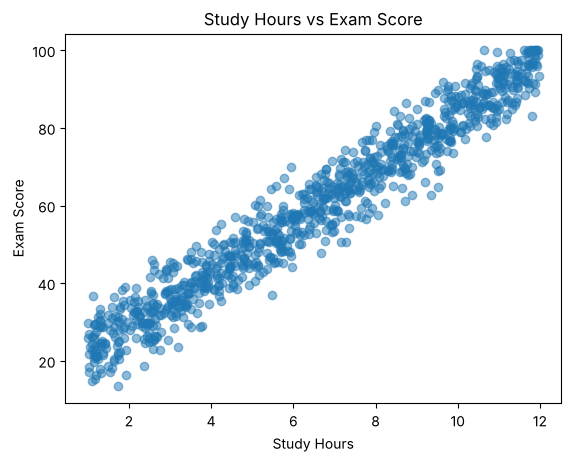

In [3]:
plt.scatter(df1['StudyHours'], df1['ExamScore'], alpha=0.5)
plt.xlabel('Study Hours'); plt.ylabel('Exam Score'); plt.title('Study Hours vs Exam Score')
plt.show()

**Q4.** Separate the dataset into an independent variable `X` and a dependent variable `y`.

In [4]:
X = df1[['StudyHours']]
y = df1['ExamScore']

**Q5.** Split the data into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(800, 1) (200, 1)


**Q6.** Build a Simple Linear Regression model and train it using the training data.

In [6]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.76]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['StudyHours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


**Q7.** Print the slope and intercept of the fitted regression line.

In [7]:
print('Slope:', slr.coef_[0])
print('Intercept:', slr.intercept_)

Slope: 6.764331148547123
Intercept: 15.48860135164751


**Q8.** Predict `ExamScore` values for the test set.

In [8]:
y_pred1 = slr.predict(X_test)
y_pred1[:5]

array([66.49165821, 68.72388749, 95.8488554 , 61.55369647, 69.40032061])

**Q9.** Calculate the model's training score and testing score.

In [9]:
print('Training score (R2):', slr.score(X_train, y_train))
print('Testing score  (R2):', slr.score(X_test, y_test))

Training score (R2): 0.9477856897467457
Testing score  (R2): 0.9477658765932852


**Q10.** Calculate the error between the actual and predicted values for the test set.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
errors = y_test - y_pred1
print('MAE :', mean_absolute_error(y_test, y_pred1))
print('MSE :', mean_squared_error(y_test, y_pred1))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred1)))

MAE : 3.9771933768334837
MSE : 25.20817703797351
RMSE: 5.020774545622768


**Q11.** Plot the actual test values and the predicted values, along with the best fit line.

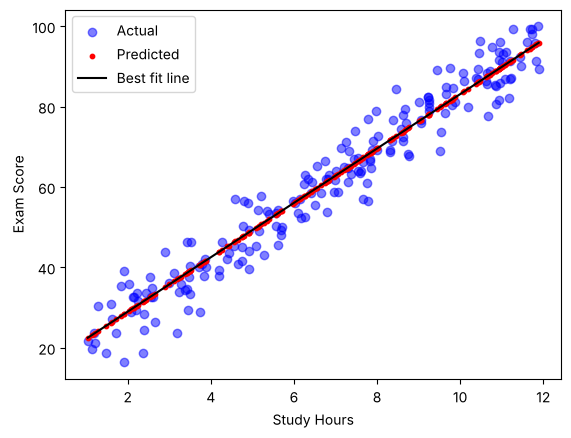

In [11]:
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.scatter(X_test, y_pred1, color='red', s=10, label='Predicted')
order = X_test['StudyHours'].argsort()
plt.plot(X_test['StudyHours'].values[order], y_pred1[order], color='black', label='Best fit line')
plt.xlabel('Study Hours'); plt.ylabel('Exam Score'); plt.legend(); plt.show()

## **Section 2: Multiple Linear Regression**

**Dataset:** `car_price_multiple.csv`
**Shape:** (5000, 4)
**Columns:** `EngineSize_L`, `Mileage_km`, `CarAge_years` (inputs), `Price_USD` (output)

**Q1.** Load `car_price_multiple.csv` into a DataFrame and display its structure (`.info()` and `.describe()`).

In [12]:
df2 = pd.read_csv('car_price_multiple.csv')
df2.info()
df2.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EngineSize_L  5000 non-null   float64
 1   Mileage_km    5000 non-null   float64
 2   CarAge_years  5000 non-null   float64
 3   Price_USD     5000 non-null   float64
dtypes: float64(4)
memory usage: 156.4 KB


,EngineSize_L,Mileage_km,CarAge_years,Price_USD
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.479148,99139.685200,7.535080,22119.486528
std,0.863222,58459.517416,4.326138,5432.659758
min,1.000000,514.000000,0.000000,5820.000000
25%,1.730000,49123.750000,3.800000,18313.570000
50%,2.450000,98220.500000,7.600000,22155.370000
75%,3.220000,151056.000000,11.300000,26030.527500
max,4.000000,199984.000000,15.000000,37912.650000


**Q2.** Confirm the dataset has no missing or duplicate values.

In [13]:
print(df2.isnull().sum())
print('Duplicates:', df2.duplicated().sum())

EngineSize_L    0
Mileage_km      0
CarAge_years    0
Price_USD       0
dtype: int64


Duplicates: 0


**Q3.** Separate the independent variables `X` (`EngineSize_L`, `Mileage_km`, `CarAge_years`) and the dependent variable `y` (`Price_USD`).

In [14]:
X = df2[['EngineSize_L', 'Mileage_km', 'CarAge_years']]
y = df2['Price_USD']

**Q4.** Split the dataset into training and testing sets using an 80-20 split.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(4000, 3) (1000, 3)


**Q5.** Build and train a Multiple Linear Regression model on the training data.

In [16]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[3231.17, -0.04,-841.69]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['EngineSize_L','Mileage_km','CarAge_years']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.491e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


**Q6.** Predict `Price_USD` for the test set.

In [17]:
y_pred2 = mlr.predict(X_test)
y_pred2[:5]
mlr_y_test, mlr_pred = y_test, y_pred2

**Q7.** Print the model's coefficients and intercept. Identify which feature has the strongest influence based on coefficient magnitude.

In [18]:
coef = pd.Series(mlr.coef_, index=X.columns)
print(coef)
print('Intercept:', mlr.intercept_)
print('Strongest (raw coefficient magnitude):', coef.abs().idxmax())
# Fairer comparison: standardized coefficients (coef * std of feature)
std_coef = (coef * X.std()).abs().sort_values(ascending=False)
print('\nStandardized influence:\n', std_coef)

EngineSize_L    3231.172577
Mileage_km        -0.044999
CarAge_years    -841.692346
dtype: float64
Intercept: 24907.810417735378
Strongest (raw coefficient magnitude): EngineSize_L

Standardized influence:
 CarAge_years    3641.277097
EngineSize_L    2789.217838
Mileage_km      2630.625522
dtype: float64


**Q8.** Calculate the training score and testing score of the model.

In [19]:
print('Training score:', mlr.score(X_train, y_train))
print('Testing score :', mlr.score(X_test, y_test))

Training score: 0.9216354020818603
Testing score : 0.9290167145655366


**Q9.** Compute MAE, MSE, RMSE, and R² score for the model's predictions.

In [20]:
from sklearn.metrics import r2_score
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
print('MAE :', mae); print('MSE :', mse)
print('RMSE:', np.sqrt(mse)); print('R2  :', r2_score(y_test, y_pred2))

MAE : 1191.0160902619114
MSE : 2219821.1724059856
RMSE: 1489.906430755296
R2  : 0.9290167145655366


**Q10.** Create a scatter plot of Actual vs Predicted prices, with a diagonal reference line representing perfect predictions.

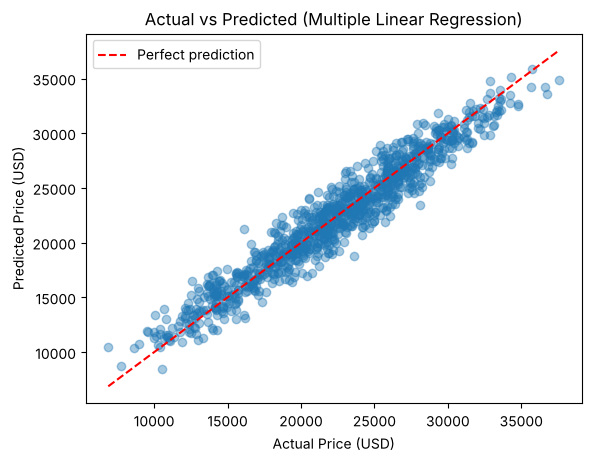

In [21]:
plt.scatter(y_test, y_pred2, alpha=0.4)
lims = [min(y_test.min(), y_pred2.min()), max(y_test.max(), y_pred2.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (USD)'); plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted (Multiple Linear Regression)'); plt.legend(); plt.show()

## **Section 3: Gradient Boosting Regressor**

**Dataset:** `laptop_price_gbr.csv`
**Shape:** (10000, 6)
**Columns:** `RAM_GB`, `Storage_GB`, `ScreenSize_inch`, `Weight_kg`, `BatteryLife_hrs` (inputs), `Price_USD` (output)

**Q1.** Load `laptop_price_gbr.csv` into a DataFrame. Check its shape and data types.

In [22]:
df3 = pd.read_csv('laptop_price_gbr.csv')
print(df3.shape)
print(df3.dtypes)

(10000, 6)
RAM_GB               int64
Storage_GB           int64
ScreenSize_inch    float64
Weight_kg          float64
BatteryLife_hrs    float64
Price_USD          float64
dtype: object


**Q2.** Confirm the dataset has no missing values.

In [23]:
print(df3.isnull().sum())

RAM_GB             0
Storage_GB         0
ScreenSize_inch    0
Weight_kg          0
BatteryLife_hrs    0
Price_USD          0
dtype: int64


**Q3.** Separate the independent variables `X` and the dependent variable `y` (`Price_USD`).

In [24]:
X = df3.drop('Price_USD', axis=1)
y = df3['Price_USD']

**Q4.** Split the dataset into training and testing sets (80-20 split, `random_state=42`).

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(8000, 5) (2000, 5)


**Q5.** Build a `GradientBoostingRegressor` model with `n_estimators=100`, `learning_rate=0.1`, and `max_depth=3`. Train it on the training data.

In [26]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

**Q6.** Predict `Price_USD` for the test set.

In [27]:
y_pred3 = gbr.predict(X_test)
y_pred3[:5]

array([ 300.4783699 , 1577.02005322,  534.85220537,  686.22119893,
       1119.44375745])

**Q7.** Evaluate the model using MAE, MSE, RMSE, and R² score.

In [28]:
mae3 = mean_absolute_error(y_test, y_pred3)
mse3 = mean_squared_error(y_test, y_pred3)
r2_gbr = r2_score(y_test, y_pred3)
print('MAE :', mae3); print('MSE :', mse3)
print('RMSE:', np.sqrt(mse3)); print('R2  :', r2_gbr)

MAE : 48.8474885544373
MSE : 3724.388217359591
RMSE: 61.02776595419163
R2  : 0.9842494014600353


**Q8.** Create a scatter plot comparing Actual vs Predicted prices, with a diagonal reference line for perfect predictions.

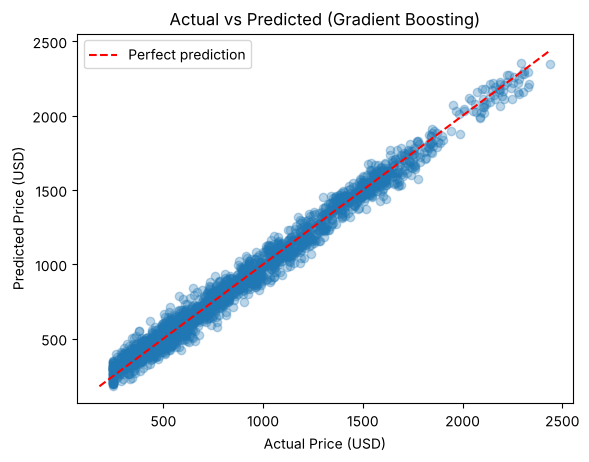

In [29]:
plt.scatter(y_test, y_pred3, alpha=0.3)
lims = [min(y_test.min(), y_pred3.min()), max(y_test.max(), y_pred3.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (USD)'); plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted (Gradient Boosting)'); plt.legend(); plt.show()

**Q9.** Extract and plot the feature importances from the trained model. Which feature contributes most to predicting `Price_USD`?

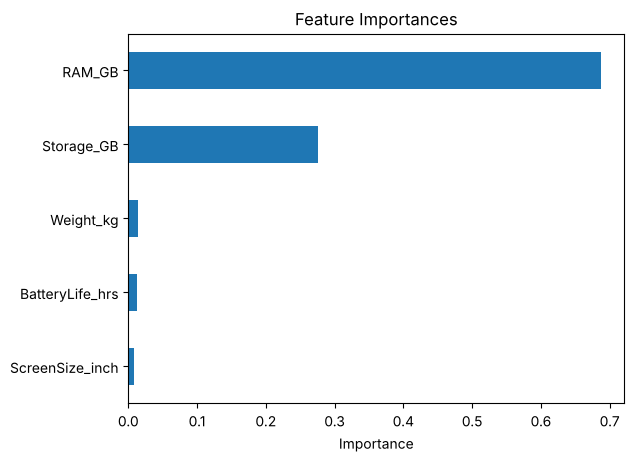

RAM_GB             0.686909
Storage_GB         0.276293
Weight_kg          0.014767
BatteryLife_hrs    0.013139
ScreenSize_inch    0.008891
dtype: float64
Most important feature: RAM_GB


In [30]:
imp = pd.Series(gbr.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh'); plt.title('Feature Importances'); plt.xlabel('Importance'); plt.show()
print(imp.sort_values(ascending=False))
print('Most important feature:', imp.idxmax())

**Q10.** Compare the R² score of this model with the Multiple Linear Regression model from Section 2 (conceptually) — which type of model would you expect to perform better on non-linear relationships, and why?

In [31]:
print('Section 2 (Multiple Linear Regression) R2:', r2_score(mlr_y_test, mlr_pred))
print('Section 3 (Gradient Boosting) R2         :', r2_gbr)
# Conceptual answer:
# Gradient Boosting is expected to do better on non-linear relationships. Linear regression can only fit
# a straight-line / additive linear combination of features, while Gradient Boosting builds many shallow
# trees sequentially, each correcting the previous errors, so it can capture non-linearity and feature
# interactions without them being specified. (Note: the two datasets differ, so the R2 comparison is
# only indicative; the real test is fitting both model types on the same data.)

Section 2 (Multiple Linear Regression) R2: 0.9290167145655366
Section 3 (Gradient Boosting) R2         : 0.9842494014600353
